# Part B: Creating and exporting the input files for both the Moselle and Garonne

## Introduction
This notebook contains _all code_ that has been used to create, preprocess and export the _input data_ to be used for the modelling performed for the paper "Assessing the Impact of Geological Map Detail on Process-Based and Data-Driven Hydrological Models" paper by do Nascimento et al. (in review). To be able to run this notebook, please ensure that you have downloaded the acompanying data of the paper. All links can be found in the data section of the paper.

Author: Thiago Nascimento (thiago.nascimento@eawag.ch)

## Requirements

**Files**

- estreams_gauging_stations.csv https://doi.org/10.5281/zenodo.14778580 (Last access: 11 February 2025)
- estreams_geology_moselle_regional_attributes.csv https://doi.org/10.5281/zenodo.14778580 (Last access: 15 February 2025)
- estreams_attributes_filtered_quality_geology_v01.csv https://github.com/thiagovmdon/LSH-quality_geology (Last access: 11 February 2025)



# Import the modules

In [19]:
import pandas as pd
import datetime as datetime
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import tqdm as tqdm
from utils.functions import find_max_unique_rows
from utils.functions import find_iterative_immediate_downstream
import geopandas as gpd
#warnings.filterwarnings("ignore")

## Configurations

In [20]:
# Path to where the EStreams dataset is stored
# Eawag
path_estreams = r'/Users/nascimth/Documents/data/EStreams'

## Mac
#path_estreams = r'/Users/thiagomedeirosdonascimento/Downloads/Python 2/Scripts/estreams_part_b/data/EStreams'

path_data = r"/Users/nascimth/Documents/data"

## Read the files

In [21]:
network_estreams_moselle_108_gauges = pd.read_csv('../data/network_estreams_moselle_108_gauges.csv', encoding='utf-8')
network_estreams_moselle_108_gauges.drop_duplicates("basin_id", inplace = True)
network_estreams_moselle_108_gauges.set_index("basin_id", inplace = True)
network_estreams_moselle_108_gauges.head()

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,irri_1990,irri_2005,stations_num_p_mean,perm_high_regi,perm_medium_regi,perm_low_regi,perm_high_glob2,perm_medium_glob2,perm_low_glob2,group
basin_id,,,,,,,,,,,,,,,,,,,,,
LU000018,0,5,Schoenfels,LU,LU_CONTACTFORM,Mamer,6.100795,49.723112,6.100795,49.723112,...,0.015,0.015,17.0,39.0,61.0,0.0,0.0,100.0,0.0,Group_1
LU000010,1,6,Hunnebuer,LU,LU_CONTACTFORM,Eisch,6.079524,49.729184,6.079524,49.729184,...,0.026,0.026,16.0,42.0,58.0,0.0,1.0,99.0,0.0,Group_1
LU000001,2,17,Bigonville,LU,LU_CONTACTFORM,Sure,5.801399,49.869821,5.801399,49.869821,...,0.000,0.000,9.0,1.0,0.0,99.0,100.0,0.0,0.0,Group_1
DERP2028,3,2674030900,Eisenschmitt,DE,DE_RP,Salm,6.718000,50.048000,6.718000,50.048000,...,0.000,0.000,10.0,80.0,7.0,13.0,79.0,20.0,1.0,Group_1
FR000183,4,A900105050,A9001050,FR,FR_EAUFRANCE,La Sarre à Laneuveville-lès-Lorquin,7.008689,48.654579,7.008689,48.654579,...,0.000,0.000,4.0,66.0,29.0,5.0,64.0,30.0,6.0,Group_1


In [22]:
network_estreams_garonne_22_gauges = pd.read_csv('../data/network_estreams_garonne_22_gauges.csv', encoding='utf-8')
network_estreams_garonne_22_gauges.drop_duplicates("basin_id", inplace = True)
network_estreams_garonne_22_gauges.set_index("basin_id", inplace = True)
network_estreams_garonne_22_gauges.head()

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,perm_medium_cont2,perm_low_cont2,lakes_depth_mean,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,52.863,47.137,NaN,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,100.000,0.000,NaN,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,49.849,50.151,NaN,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,97.803,0.000,3.648649,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,94.518,5.483,NaN,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1


In [23]:
# Load geology data - regional scale for the Garonne
geology_regional = pd.read_csv("../data/estreams_geology_garonne_regional_attributes.csv", encoding='utf-8')

geology_regional.set_index("basin_id", inplace = True)

# Create a dictionary to map permeability classes to corresponding columns
permeability_columns = {
    "high": [ "lit_fra_Alluvium",

             'lit_fra_Sand, gravel and pebbles'    
        ],
    
    "medium": ['lit_fra_Carbonate rocks', 
               'lit_fra_Limestones', 
               'lit_fra_Limestones, sandstones and gravels', 
               'lit_fra_Limestones, sandstones and marls', 
               'lit_fra_Molasses and clays',  
               'lit_fra_Sands and clays',
                'lit_fra_Sedimentary rocks',
               'lit_fra_Sediments mesosoics',
            'lit_fra_Schists, gneisses, granites', 
             ],
    
    "low": ['lit_fra_Impermeable', 
            'lit_fra_Inland water', 
            'lit_fra_Magmatic rocks', 
            'lit_fra_Massif', 
            'lit_fra_Plutonic rocks',
            'lit_fra_Shales',
            'lit_fra_Granitoids',

                   ]
}

# Iterate over the permeability columns and calculate the area for each class
for permeability_class, columns in permeability_columns.items():
    geology_regional[f'area_perm_{permeability_class}'] = geology_regional[columns].sum(axis=1)



# Drop unnecessary columns
geology_regional = geology_regional[["area_perm_high", "area_perm_medium", "area_perm_low"]]

# Rename the columns
geology_regional.columns = ["perm_high_regi", "perm_medium_regi", "perm_low_regi"]


# Concatenation
network_estreams_garonne_22_gauges[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]] = geology_regional[["perm_high_regi", "perm_medium_regi", "perm_low_regi"]]

for basin_id in network_estreams_garonne_22_gauges.index.tolist():

    # Extract and divide by 100
    v1 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] / 100
    v2 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] / 100
    v3 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] = v1 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] = v2 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] = v3 * 100

network_estreams_garonne_22_gauges

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0
FR004140,5,O163401001,La VixiÃ¨ge Ã Belpech,FR,FR_EAUFRANCE,La Vixiège à Belpech,1.749951,43.201718,1.749951,43.201718,...,0.000000,195.640,718.685,0.000000,0.822625,0.817920,Group_1,0.0,100.0,0.0
FR004149,6,O184402001,La LÃ¨ze Ã LÃ©zat-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Lézat-sur-Lèze,1.352878,43.280809,1.352878,43.280809,...,12.564601,178.485,775.260,0.016207,0.853714,0.893136,Group_1,0.0,94.0,6.0
FR004152,7,O187401001,La LÃ¨ze Ã Labarthe-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Labarthe-sur-Lèze,1.406594,43.451190,1.406594,43.451190,...,8.638464,161.330,740.220,0.011670,0.866051,0.889248,Group_1,5.0,91.0,4.0
FR001593,8,O222251001,O2222510,FR,FR_EAUFRANCE,L'Hers à Toulouse [Pont de Périole],1.480100,43.627770,1.480100,43.627770,...,9.651561,138.335,665.030,0.014513,0.820100,0.826636,Group_1,1.0,99.0,0.0


In [24]:
for basin_id in network_estreams_garonne_22_gauges.index.tolist():

    # Extract and divide by 100
    v1 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] / 100
    v2 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] / 100
    v3 = network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] / 100

    # Round all values to one decimal place
    v1 = round(v1, 2)
    v2 = round(v2, 2)
    v3 = round(v3, 2)

    # Ensure the sum is exactly 1 by adjusting the largest value
    diff = 1 - (v1 + v2 + v3)

    if diff != 0:
        # Adjust the value that was the largest before rounding
        if max(v1, v2, v3) == v1:
            v1 += diff
        elif max(v1, v2, v3) == v2:
            v2 += diff
        else:
            v3 += diff

    # Assign back
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_high_regi"] = v1 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_medium_regi"] = v2 * 100
    network_estreams_garonne_22_gauges.loc[basin_id, "perm_low_regi"] = v3 * 100

network_estreams_garonne_22_gauges

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0
FR004140,5,O163401001,La VixiÃ¨ge Ã Belpech,FR,FR_EAUFRANCE,La Vixiège à Belpech,1.749951,43.201718,1.749951,43.201718,...,0.000000,195.640,718.685,0.000000,0.822625,0.817920,Group_1,0.0,100.0,0.0
FR004149,6,O184402001,La LÃ¨ze Ã LÃ©zat-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Lézat-sur-Lèze,1.352878,43.280809,1.352878,43.280809,...,12.564601,178.485,775.260,0.016207,0.853714,0.893136,Group_1,0.0,94.0,6.0
FR004152,7,O187401001,La LÃ¨ze Ã Labarthe-sur-LÃ¨ze,FR,FR_EAUFRANCE,La Lèze à Labarthe-sur-Lèze,1.406594,43.451190,1.406594,43.451190,...,8.638464,161.330,740.220,0.011670,0.866051,0.889248,Group_1,5.0,91.0,4.0
FR001593,8,O222251001,O2222510,FR,FR_EAUFRANCE,L'Hers à Toulouse [Pont de Périole],1.480100,43.627770,1.480100,43.627770,...,9.651561,138.335,665.030,0.014513,0.820100,0.826636,Group_1,1.0,99.0,0.0


In [25]:
network_estreams_garonne_and_moselle = pd.concat([network_estreams_garonne_22_gauges, network_estreams_moselle_108_gauges])
network_estreams_garonne_and_moselle

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,846.800,888.775,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,337.990,819.790,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,919.800,1040.250,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,12.385889,117.165,657.730,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,380.330,832.930,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,106,2628050400,Pruemzurlay,DE,DE_RP,Pruem,6.437000,49.868000,6.437000,49.868000,...,NaN,NaN,NaN,NaN,NaN,NaN,Group_7,16.0,19.0,65.0
FR003271,107,A782101001,La Seille Ã Nomeny,FR,FR_EAUFRANCE,La Seille à Nomeny,6.227788,48.888271,6.227788,48.888271,...,NaN,NaN,NaN,NaN,NaN,NaN,Group_7,8.0,92.0,0.0
FR003301,108,A930108040,La Sarre Ã Wittring,FR,FR_EAUFRANCE,La Sarre à Wittring,7.150066,49.053225,7.150066,49.053225,...,NaN,NaN,NaN,NaN,NaN,NaN,Group_7,17.0,83.0,0.0


In [26]:
# Creating the random permeability percentages
network_estreams_garonne_and_moselle = network_estreams_garonne_and_moselle.copy()

rng = np.random.default_rng(seed=42)

# Step 1: draw random proportions
perms = rng.dirichlet(alpha=[1, 1, 1], size=len(network_estreams_garonne_and_moselle))

# Step 2: convert to percentages
perms = perms * 100.0

# Step 3: round to 1 decimal, fix residual
perms_rounded = np.floor(perms * 10) / 10  # floor to 1 decimal

residual = 100.0 - perms_rounded.sum(axis=1)

# Step 4: distribute residual (0.1 steps) safely
for i in range(len(network_estreams_garonne_and_moselle)):
    n_steps = int(round(residual[i] * 10))
    if n_steps > 0:
        idx = np.argsort(perms[i] - perms_rounded[i])[-n_steps:]
        perms_rounded[i, idx] += 0.1

network_estreams_garonne_and_moselle["perm_high_rand"] = perms_rounded[:, 0]
network_estreams_garonne_and_moselle["perm_medium_rand"] = perms_rounded[:, 1]
network_estreams_garonne_and_moselle["perm_low_rand"] = perms_rounded[:, 2]


In [27]:
# Setting some new columns
network_estreams_garonne_and_moselle["lakes_depth_mean"] = network_estreams_garonne_and_moselle.lakes_tot_vol / network_estreams_garonne_and_moselle.lakes_tot_area
network_estreams_garonne_and_moselle["lakes_depth_mean_norm"] = (network_estreams_garonne_and_moselle.lakes_tot_vol / network_estreams_garonne_and_moselle.area_estreams)*1000
network_estreams_garonne_and_moselle["q_mean_yr"]= network_estreams_garonne_and_moselle.q_mean*365
network_estreams_garonne_and_moselle["p_mean_yr"]= network_estreams_garonne_and_moselle.p_mean*365
network_estreams_garonne_and_moselle["norm_ups_cap"]= network_estreams_garonne_and_moselle["lakes_depth_mean_norm"]/network_estreams_garonne_and_moselle["p_mean_yr"]


In [28]:
# Adjusted permeability classes
network_estreams_garonne_and_moselle["perm_high_glob2"] = network_estreams_garonne_and_moselle["perm_high_glob"]
network_estreams_garonne_and_moselle["perm_medium_glob2"] = network_estreams_garonne_and_moselle["perm_medium_glob"] + network_estreams_garonne_and_moselle["perm_low_glob"]
network_estreams_garonne_and_moselle["perm_low_glob2"] = network_estreams_garonne_and_moselle["perm_verylow_glob"]

network_estreams_garonne_and_moselle["perm_high_cont2"] = network_estreams_garonne_and_moselle["perm_high_cont"]
network_estreams_garonne_and_moselle["perm_medium_cont2"] = network_estreams_garonne_and_moselle["perm_medium_cont"] + network_estreams_garonne_and_moselle["perm_low_cont"]
network_estreams_garonne_and_moselle["perm_low_cont2"] = network_estreams_garonne_and_moselle["perm_verylow_cont"]

network_estreams_garonne_and_moselle

,Unnamed: 0,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,...,norm_ups_cap,NSE,NSElstm,group,perm_high_regi,perm_medium_regi,perm_low_regi,perm_high_rand,perm_medium_rand,perm_low_rand
basin_id,,,,,,,,,,,,,,,,,,,,,
FR004136,0,O149431003,Le Touyre Ã Lavelanet et Ã Saint-Quentin-la-...,FR,FR_EAUFRANCE,Le Touyre à Lavelanet et à Saint-Quentin-la-Tour,1.850824,42.940862,1.850824,42.940862,...,0.000000,0.700021,0.815218,Group_1,0.0,45.0,55.0,33.7,32.8,33.5
FR001547,1,O062401001,O0624010,FR,FR_EAUFRANCE,Le Volp à Montberaud et à Sainte-Croix-Volvestre,1.141456,43.144783,1.141456,43.144783,...,0.000000,0.823456,0.876788,Group_1,0.0,58.0,42.0,15.4,4.7,79.9
FR004091,2,O023402001,Le Ger Ã Aspet [2],FR,FR_EAUFRANCE,Le Ger à Aspet [2],0.795350,43.021419,0.795350,43.021419,...,0.000000,0.723698,0.848994,Group_1,0.0,49.0,51.0,30.6,67.7,1.7
FR001592,3,O221501001,O2215010,FR,FR_EAUFRANCE,La Saune à Quint-Fonsegrives,1.548308,43.574698,1.548308,43.574698,...,0.018831,0.809932,0.811849,Group_1,0.0,100.0,0.0,47.4,3.2,49.4
FR001577,4,O158461001,O1584610,FR,FR_EAUFRANCE,Le Douctouyre à Dun et à Vira [Engraviès],1.772643,43.043560,1.772643,43.043560,...,0.000000,0.852887,0.849163,Group_1,0.0,95.0,5.0,51.7,11.5,36.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DERP2007,106,2628050400,Pruemzurlay,DE,DE_RP,Pruem,6.437000,49.868000,6.437000,49.868000,...,0.003874,NaN,NaN,Group_7,16.0,19.0,65.0,26.1,14.3,59.6
FR003271,107,A782101001,La Seille Ã Nomeny,FR,FR_EAUFRANCE,La Seille à Nomeny,6.227788,48.888271,6.227788,48.888271,...,0.052949,NaN,NaN,Group_7,8.0,92.0,0.0,62.1,31.0,6.9
FR003301,108,A930108040,La Sarre Ã Wittring,FR,FR_EAUFRANCE,La Sarre à Wittring,7.150066,49.053225,7.150066,49.053225,...,0.066980,NaN,NaN,Group_7,17.0,83.0,0.0,26.4,43.7,29.9


In [29]:
cols = ["perm_high_glob2", "perm_medium_glob2", "perm_low_glob2"]

# Step 1: compute row-wise sum
row_sum = network_estreams_garonne_and_moselle[cols].sum(axis=1)

# Step 2: normalize to percentage
perc = network_estreams_garonne_and_moselle[cols].div(row_sum, axis=0) * 100

# Step 3: round to integers
perc_rounded = perc.round(0).astype(float)

# Step 4: fix rounding errors so rows sum to exactly 100
diff = 100 - perc_rounded.sum(axis=1)

# Add the difference to the largest component in each row
max_col_idx = perc.idxmax(axis=1)
for i, col in max_col_idx.items():
    perc_rounded.loc[i, col] += diff.loc[i]

# Step 5: assign back
network_estreams_garonne_and_moselle[cols] = perc_rounded
network_estreams_garonne_and_moselle[cols]

,perm_high_glob2,perm_medium_glob2,perm_low_glob2
basin_id,,,
FR004136,23.0,77.0,0.0
FR001547,13.0,87.0,0.0
FR004091,4.0,87.0,9.0
FR001592,11.0,89.0,0.0
FR001577,3.0,97.0,0.0
...,...,...,...
DERP2007,7.0,93.0,0.0
FR003271,0.0,100.0,0.0
FR003301,15.0,85.0,0.0


In [30]:
cols = ["perm_high_cont2", "perm_medium_cont2", "perm_low_cont2"]

# Step 1: compute row-wise sum
row_sum = network_estreams_garonne_and_moselle[cols].sum(axis=1)

# Step 2: normalize to percentage
perc = network_estreams_garonne_and_moselle[cols].div(row_sum, axis=0) * 100

# Step 3: round to integers
perc_rounded = perc.round(0).astype(float)

# Step 4: fix rounding errors so rows sum to exactly 100
diff = 100 - perc_rounded.sum(axis=1)

# Add the difference to the largest component in each row
max_col_idx = perc.idxmax(axis=1)
for i, col in max_col_idx.items():
    perc_rounded.loc[i, col] += diff.loc[i]

# Step 5: assign back
network_estreams_garonne_and_moselle[cols] = perc_rounded
network_estreams_garonne_and_moselle[cols]

,perm_high_cont2,perm_medium_cont2,perm_low_cont2
basin_id,,,
FR004136,0.0,53.0,47.0
FR001547,0.0,100.0,0.0
FR004091,0.0,50.0,50.0
FR001592,2.0,98.0,0.0
FR001577,0.0,95.0,5.0
...,...,...,...
DERP2007,13.0,15.0,72.0
FR003271,11.0,88.0,1.0
FR003301,16.0,83.0,1.0


In [31]:
cols = ["perm_high_regi", "perm_medium_regi", "perm_low_regi"]
network_estreams_garonne_and_moselle[cols]

,perm_high_regi,perm_medium_regi,perm_low_regi
basin_id,,,
FR004136,0.0,45.0,55.0
FR001547,0.0,58.0,42.0
FR004091,0.0,49.0,51.0
FR001592,0.0,100.0,0.0
FR001577,0.0,95.0,5.0
...,...,...,...
DERP2007,16.0,19.0,65.0
FR003271,8.0,92.0,0.0
FR003301,17.0,83.0,0.0


In [32]:
network_estreams_garonne_and_moselle.loc["FR001604", cols]

perm_high_regi      14.0
perm_medium_regi    47.0
perm_low_regi       39.0
Name: FR001604, dtype: object

### Exporting the attributes.csv file

In [ ]:
network_estreams_garonne_and_moselle.to_csv('../data/attributes.csv', encoding='utf-8')
network_estreams_garonne_and_moselle.to_csv('../data/network_estreams_garonne_and_moselle_130_gauges.csv', encoding='utf-8')

### Exporting the timeseries as netcdfs for the further simulations
Note that here we use the corrections for precipitation, previously computed for the Garonne basin.

In [15]:
garonne_clim = pd.read_csv("../results/precipitation_correction/garonne_clim_with_kpre.csv", encoding='utf-8')
garonne_clim.set_index("basin_id", inplace = True)

In [ ]:
# === CONFIG ===
path_estreams = r"/Users/nascimth/Documents/"
input_dir = path_estreams+"data/EStreams/time_series_csv//"
output_dir = r"/Users/nascimth/Documents/data/EStreams/time_series//"
start_date = "1980-10-01"
end_date = "2020-09-30"

# Variables to keep (and interpolate if missing)
forcing_vars = ["p_mean", "t_min", "t_max", "swr_mean", "sp_mean", "t_mean", "pet_mean"]
target_var = "q_mean"

selected_basins = garonne_clim.index.tolist()
  
# Loop through selected basin ids
for basin_id in tqdm.tqdm(selected_basins):
    file = f"estreams_timeseries_{basin_id}.csv"
    file_path = os.path.join(input_dir, file)
    k_p = garonne_clim.loc[basin_id, "k_pre"]

    area = network_estreams_garonne_and_moselle.loc[basin_id, "area_estreams"]

    if not os.path.isfile(file_path):
        print(f"File not found for {basin_id}, skipping.")
        continue

    try:
        df = pd.read_csv(file_path, parse_dates=["date"])
    except Exception as e:
        print(f"Error reading {file}: {e}")
        continue

    # Clip to date range
    df = df[(df["date"] >= start_date) & (df["date"] <= end_date)].copy()

    if df.empty:
        print(f"Skipping {basin_id} (no data in range)")
        continue

    df.set_index("date", inplace=True)

    # Interpolate meteorological variables
    # === Fill NaNs in forcing variables using daily climatology ===
    for var in forcing_vars:
        if var not in df.columns:
            continue

        # Ensure datetime index
        df.index = pd.to_datetime(df.index)

        # Compute long-term daily climatology (mean per day-of-year)
        climatology = df[var].groupby(df.index.dayofyear).mean()

        # Find where values are missing
        mask = df[var].isna()
        if mask.any():
            doys = df.index.dayofyear
            df.loc[mask, var] = [climatology.get(doy, np.nan) for doy in doys[mask]]

    # Replace invalid values with NaN (e.g., -999 or empty)
    df = df.replace(-999, np.nan)
    df = df.astype(float)

    # Convert from m3/s to mm/day
    df[target_var] = (df[target_var] * 86400 * 1000) / (area * 1000000)
    df[target_var] =  df[target_var].round(2)

    # Keep only desired columns
    columns = forcing_vars + [target_var]
    df = df[columns]

    df["p_mean"] = df["p_mean"] * k_p
    
    # Convert to xarray
    ds = df.to_xarray()

    # Save one NetCDF per basin
    #os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"{basin_id}.nc")
    ds.to_netcdf(out_path)

100%|██████████| 22/22 [00:01<00:00, 13.14it/s]


### Export the random training/validation/test sets

In [33]:
# Here is a refined version that ensures DEBU1958 and DEBU1959 are placed in non-adjacent folds (train/test):

import random

random.seed(42)

# ---------------------------------------------------------
# INPUT LISTS
# ---------------------------------------------------------
moselle_basins = network_estreams_moselle_108_gauges.index.tolist()
garonne_basins = network_estreams_garonne_22_gauges.index.tolist()

# Constrained basins (close to outlet)
b1 = "DEBU1958"
b2 = "DEBU1959"

# Remove constrained basins from Moselle list
moselle_basins.remove(b1)
moselle_basins.remove(b2)

# Shuffle independently (important for spacing)
random.shuffle(moselle_basins)
random.shuffle(garonne_basins)

num_splits = 5

# ---------------------------------------------------------
# INITIALIZE FOLDS
# ---------------------------------------------------------
folds = [[] for _ in range(num_splits)]

# ---------------------------------------------------------
# PLACE CONSTRAINED BASINS IN NON-ADJACENT FOLDS
# (guarantees: if one is test, the other is train)
# ---------------------------------------------------------
fold_ids = list(range(num_splits))
random.shuffle(fold_ids)


f1 = fold_ids[0]

valid_f2 = [
    f for f in fold_ids[1:]
    if f not in {(f1 - 1) % num_splits, f1, (f1 + 1) % num_splits}
]

assert valid_f2, "No valid fold for constrained basin placement!"

f2 = valid_f2[0]

folds[f1].append(b1)
folds[f2].append(b2)

# ---------------------------------------------------------
# DISTRIBUTE MOSSELLE BASINS (ROUND-ROBIN)
# ---------------------------------------------------------
for i, b in enumerate(moselle_basins):
    folds[i % num_splits].append(b)

# ---------------------------------------------------------
# DISTRIBUTE GARONNE BASINS (ROUND-ROBIN)
# ---------------------------------------------------------
for i, b in enumerate(garonne_basins):
    folds[i % num_splits].append(b)

# ---------------------------------------------------------
# BUILD SPLITS (TRAIN / VAL / TEST)
# ---------------------------------------------------------
splits = []

for i in range(num_splits):
    test = folds[i]
    val = folds[(i + 1) % num_splits]
    train = [
        b
        for j, fold in enumerate(folds)
        if j != i and j != (i + 1) % num_splits
        for b in fold
    ]
    splits.append((train, val, test))

# ---------------------------------------------------------
# VALIDATION
# ---------------------------------------------------------
all_basins = set(moselle_basins + garonne_basins + [b1, b2])

all_test = set(b for _, _, t in splits for b in t)
all_val = set(b for _, v, _ in splits for b in v)

assert all_test == all_basins, "Test coverage incomplete!"
assert all_val == all_basins, "Validation coverage incomplete!"

for train, val, test in splits:

    # Critical constraint
    if b1 in test:
        assert b2 in train, "DEBU1959 must be in TRAIN when DEBU1958 is in TEST!"
    if b2 in test:
        assert b1 in train, "DEBU1958 must be in TRAIN when DEBU1959 is in TEST!"

    # Never together
    assert not (b1 in test and b2 in test), "DEBU1958 & DEBU1959 together!"

    # Spatial diversity
    assert any(b in moselle_basins or b in [b1, b2] for b in test), "Moselle missing in test!"
    assert any(b in garonne_basins for b in test), "Garonne missing in test!"

In [18]:
for i, (train, val, test) in enumerate(splits, 1):
    print(f"Split {i}:")
    print(f"  Train: {train}")
    print(f"  Validation: {val}")
    print(f"  Test: {test}")

Split 1:
  Train: ['FR003249', 'DERP2013', 'FR003307', 'FR003268', 'BEWA0119', 'LU000009', 'LU000019', 'LU000017', 'DERP2004', 'LU000007', 'BEWA0106', 'FR000144', 'FR000137', 'FR000132', 'DERP2006', 'FR003300', 'FR003296', 'LU000002', 'FR003256', 'DERP2007', 'FR003250', 'FR004136', 'FR004143', 'FR004119', 'FR004132', 'DEBU1959', 'FR000154', 'FR000159', 'DERP2033', 'LU000005', 'FR000142', 'LU000008', 'FR000201', 'FR000184', 'DERP2017', 'LU000015', 'BEWA0066', 'FR000125', 'LU000013', 'LU000014', 'LU000018', 'DERP2005', 'FR003284', 'FR003271', 'DERP2021', 'LU000006', 'DERP2028', 'FR001547', 'FR004137', 'FR001577', 'FR001604', 'FR003267', 'FR003274', 'FR003288', 'FR003241', 'FR003251', 'DERP2011', 'DERP2027', 'FR003301', 'FR000169', 'DERP2008', 'DEBU1957', 'FR000156', 'FR003257', 'DERP2024', 'DERP2014', 'LU000016', 'LU000011', 'FR000183', 'DERP2010', 'FR000128', 'FR003302', 'FR004114', 'FR004162', 'FR004091', 'FR001584']
  Validation: ['DEBU1958', 'FR003261', 'LU000010', 'DERP2036', 'FR003

In [178]:
output_dir = "../data/"

# Save each split to text files
for i, (train, val, test) in enumerate(splits, 1):  # Start index at 1
    with open(f"{output_dir}/train{i}.txt", "w") as f:
        f.write("\n".join(train))
    with open(f"{output_dir}/val{i}.txt", "w") as f:
        f.write("\n".join(val))
    with open(f"{output_dir}/test{i}.txt", "w") as f:
        f.write("\n".join(test))

print(f"Saved {len(splits)} splits to folder '{output_dir}'")

Saved 5 splits to folder '../data/'


In [34]:
# Here is a refined version that ensures DEBU1958 and DEBU1959 are placed in non-adjacent folds (train/test):

import random

random.seed(42)

# ---------------------------------------------------------
# INPUT LISTS
# ---------------------------------------------------------
moselle_basins = network_estreams_moselle_108_gauges.index.tolist()
garonne_basins = network_estreams_garonne_22_gauges.index.tolist()

# Constrained basins (close to outlet)
b1 = "DEBU1958"
b2 = "DEBU1959"

# Remove constrained basins from Moselle list
moselle_basins.remove(b1)
moselle_basins.remove(b2)

# Shuffle independently (important for spacing)
random.shuffle(moselle_basins)
random.shuffle(garonne_basins)

num_splits = 10

# ---------------------------------------------------------
# INITIALIZE FOLDS
# ---------------------------------------------------------
folds = [[] for _ in range(num_splits)]

# ---------------------------------------------------------
# PLACE CONSTRAINED BASINS IN NON-ADJACENT FOLDS
# (guarantees: if one is test, the other is train)
# ---------------------------------------------------------
fold_ids = list(range(num_splits))
random.shuffle(fold_ids)


f1 = fold_ids[0]

valid_f2 = [
    f for f in fold_ids[1:]
    if f not in {(f1 - 1) % num_splits, f1, (f1 + 1) % num_splits}
]

assert valid_f2, "No valid fold for constrained basin placement!"

f2 = valid_f2[0]

folds[f1].append(b1)
folds[f2].append(b2)

# ---------------------------------------------------------
# DISTRIBUTE MOSSELLE BASINS (ROUND-ROBIN)
# ---------------------------------------------------------
for i, b in enumerate(moselle_basins):
    folds[i % num_splits].append(b)

# ---------------------------------------------------------
# DISTRIBUTE GARONNE BASINS (ROUND-ROBIN)
# ---------------------------------------------------------
for i, b in enumerate(garonne_basins):
    folds[i % num_splits].append(b)

# ---------------------------------------------------------
# BUILD SPLITS (TRAIN / VAL / TEST)
# ---------------------------------------------------------
splits = []

for i in range(num_splits):
    test = folds[i]
    val = folds[(i + 1) % num_splits]
    train = [
        b
        for j, fold in enumerate(folds)
        if j != i and j != (i + 1) % num_splits
        for b in fold
    ]
    splits.append((train, val, test))

# ---------------------------------------------------------
# VALIDATION
# ---------------------------------------------------------
all_basins = set(moselle_basins + garonne_basins + [b1, b2])

all_test = set(b for _, _, t in splits for b in t)
all_val = set(b for _, v, _ in splits for b in v)

assert all_test == all_basins, "Test coverage incomplete!"
assert all_val == all_basins, "Validation coverage incomplete!"

for train, val, test in splits:

    # Critical constraint
    if b1 in test:
        assert b2 in train, "DEBU1959 must be in TRAIN when DEBU1958 is in TEST!"
    if b2 in test:
        assert b1 in train, "DEBU1958 must be in TRAIN when DEBU1959 is in TEST!"

    # Never together
    assert not (b1 in test and b2 in test), "DEBU1958 & DEBU1959 together!"

    # Spatial diversity
    assert any(b in moselle_basins or b in [b1, b2] for b in test), "Moselle missing in test!"
    assert any(b in garonne_basins for b in test), "Garonne missing in test!"

In [35]:
for i, (train, val, test) in enumerate(splits, 1):
    print(f"Split {i}:")
    print(f"  Train: {train}")
    print(f"  Validation: {val}")
    print(f"  Test: {test}")

Split 1:
  Train: ['FR003249', 'FR003307', 'BEWA0119', 'LU000019', 'DERP2004', 'BEWA0106', 'FR000137', 'DERP2006', 'FR003296', 'FR003256', 'FR003250', 'FR004136', 'FR004119', 'FR000154', 'DERP2033', 'FR000142', 'FR000201', 'DERP2017', 'BEWA0066', 'LU000013', 'LU000018', 'FR003284', 'DERP2021', 'DERP2028', 'FR001547', 'FR001577', 'DEBU1958', 'FR003267', 'FR003288', 'FR003251', 'DERP2027', 'FR000169', 'DEBU1957', 'FR003257', 'DERP2014', 'LU000011', 'DERP2010', 'FR003302', 'FR004114', 'FR004091', 'FR000200', 'BEWA0107', 'FR000185', 'FR003272', 'DERP2018', 'LU000001', 'FR003254', 'DEBU1956', 'FR003246', 'FR003275', 'DERP2015', 'FR004133', 'FR001526', 'LU000010', 'FR003239', 'FR000124', 'FR003262', 'DERP2022', 'DERP2016', 'FR003293', 'FR000138', 'DERP2023', 'FR003252', 'FR001545', 'FR001544', 'DERP2013', 'FR003268', 'LU000009', 'LU000017', 'LU000007', 'FR000144', 'FR000132', 'FR003300', 'LU000002', 'DERP2007', 'FR004143', 'FR004132', 'DEBU1959', 'FR000159', 'LU000005', 'LU000008', 'FR000184

In [36]:
output_dir = "../data/"

# Save each split to text files
for i, (train, val, test) in enumerate(splits, 1):  # Start index at 1
    with open(f"{output_dir}/train{i}.txt", "w") as f:
        f.write("\n".join(train))
    with open(f"{output_dir}/val{i}.txt", "w") as f:
        f.write("\n".join(val))
    with open(f"{output_dir}/test{i}.txt", "w") as f:
        f.write("\n".join(test))

print(f"Saved {len(splits)} splits to folder '{output_dir}'")

Saved 10 splits to folder '../data/'


In [233]:
import geopandas as gpd
moselle=gpd.read_file(r"/Users/nascimth/Documents/data/gis/paper_moselle_superflexpy/shps/moselle_delienation.shp")
rivers_moselle=gpd.read_file(r"/Users/nascimth/Documents/data/gis/paper_moselle_superflexpy/shps/rivers_moselle.shp")
rivers_garonne=gpd.read_file(path_data+"/gis/paper_moselle_superflexpy/shps/garonne/rivers_garonne.shp")
garonne=gpd.read_file(r"/Users/nascimth/Documents/data/gis/paper_moselle_superflexpy/shps/garonne.shp")

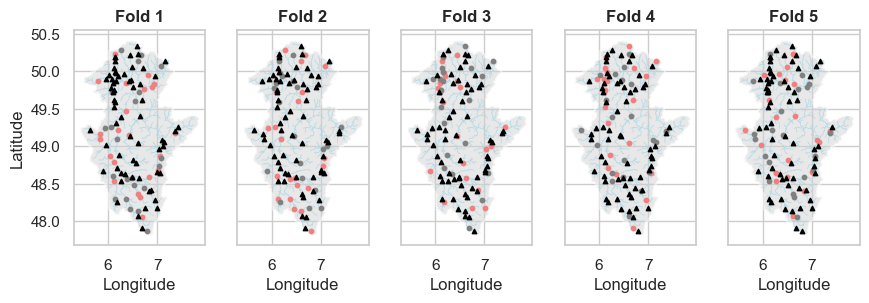

In [243]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

def read_basin_list(path):
    with open(path, "r") as f:
        return [line.strip() for line in f if line.strip()]
folds = [
    {
        "train": "../data/train1.txt",
        "val":   "../data/val1.txt",
        "test":  "../data/test1.txt",
    },
    {
        "train": "../data/train2.txt",
        "val":   "../data/val2.txt",
        "test":  "../data/test2.txt",
    },
    {
        "train": "../data/train3.txt",
        "val":   "../data/val3.txt",
        "test":  "../data/test3.txt",
    },
    {
        "train": "../data/train4.txt",
        "val":   "../data/val4.txt",
        "test":  "../data/test4.txt",
    },
    {
        "train": "../data/train5.txt",
        "val":   "../data/val5.txt",
        "test":  "../data/test5.txt",
    },]

def build_fold_coords(folds, network_estreams):
    fold_coords = []

    for fold in folds:
        train_ids = read_basin_list(fold["train"])
        val_ids   = read_basin_list(fold["val"])
        test_ids  = read_basin_list(fold["test"])

        fold_coords.append({
            "train": network_estreams.loc[
                [b for b in train_ids if b in network_estreams.index]
            ],
            "val": network_estreams.loc[
                [b for b in val_ids if b in network_estreams.index]
            ],
            "test": network_estreams.loc[
                [b for b in test_ids if b in network_estreams.index]
            ],
        })

    return fold_coords

def plot_basin_folds(
    basin_outline,
    basin_rivers,
    fold_coords,
    df_all,
    outfile,
    nrows,
    ncols,
    figsize,
    legend_on=True,
):
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        if i < len(fold_coords):
            basin_outline.plot(ax=ax, color="lightgray", linewidth=1, alpha=0.5)
            basin_rivers.plot(ax=ax, color="lightblue", linewidth=0.5, alpha=0.75)

            # Evaluation (test) – coral circle
            # Validation – black circle
            ax.scatter(
                fold_coords[i]["val"]["lon"],
                fold_coords[i]["val"]["lat"],
                color="gray",
                s=10,
                marker="o",
                zorder=3,
            )

            # Calibration – black triangle
            ax.scatter(
                fold_coords[i]["train"]["lon"],
                fold_coords[i]["train"]["lat"],
                color="black",
                s=10,
                marker="^",
                zorder=4,
            )
            ax.scatter(
                fold_coords[i]["test"]["lon"],
                fold_coords[i]["test"]["lat"],
                color="lightcoral",
                s=10,
                marker="o",
                zorder=2,
            )
            ax.set_title(f"Fold {i+1}", fontweight="bold")

        else:
            ax.axis("off")
            continue

        # Axis labels
        if i < ncols * (nrows - 1):
            ax.set_xlabel("")
        else:
            ax.set_xlabel("Longitude")

        if i % ncols != 0:
            ax.set_ylabel("")
        else:
            ax.set_ylabel("Latitude")

        ax.grid(True)

    # Legend
    calibration_handle = mlines.Line2D(
        [], [], color="black", marker="^", linestyle="None",
        markersize=8, label="Calibration (train)"
    )
    validation_handle = mlines.Line2D(
        [], [], color="black", marker="o", linestyle="None",
        markersize=8, label="Validation"
    )
    test_handle = mlines.Line2D(
        [], [], color="lightcoral", marker="o", linestyle="None",
        markersize=8, label="Evaluation (test)"
    )

    if legend_on == True:
        fig.legend(
            handles=[calibration_handle, validation_handle, test_handle],
            loc="lower center",
            ncol=3,
            frameon=False,
        )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(outfile, dpi=300)
    plt.show()


fold_coords = build_fold_coords(folds, network_estreams_moselle_108_gauges)

plot_basin_folds(
    basin_outline=moselle,
    basin_rivers=rivers_moselle,
    fold_coords=fold_coords,
    df_all=network_estreams_moselle_108_gauges,
    outfile="../results/figs/figures/FigSX_Moselle_LSTM.png",
    nrows=1,
    ncols=5,
    figsize=(9, 3),
    legend_on=False,

)

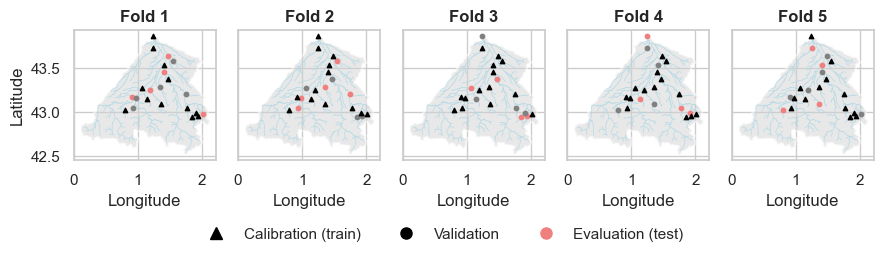

In [244]:
fold_coords = build_fold_coords(folds, network_estreams_garonne_22_gauges)
plot_basin_folds(
    basin_outline=garonne,
    basin_rivers=rivers_garonne,
    fold_coords=fold_coords,
    df_all=network_estreams_garonne_22_gauges,
    outfile="../results/figs/figures/FigSX_Garonne_LSTM.png",
    nrows=1,
    ncols=5,
    figsize=(9, 3),
)

# End